# Imports

In [10]:
import numpy as np
from src.get_gender_data import get_founder_gender
from src.scrape_wiki import scrape_wiki_table
from src.get_gender_data import get_founder_gender, _parse_names
from src.filter_df import filter_df

import pandas as pd
import os

# Functions

In [11]:
def rescue_unknowns(df, founder_col, gender_col):
    """Re-process only rows where gender is unknown or contains unknown."""
    mask = df[gender_col].apply(lambda x: 'unknown' in str(x).lower() if x is not None else True)
    unknown_count = mask.sum()

    print(f"Attempting to rescue {unknown_count} unknowns in {gender_col}...")

    # Targeted update
    df.loc[mask, gender_col] = df.loc[mask, founder_col].apply(lambda x: get_founder_gender(x, use_web_search=True))

    new_unknown_count = df[gender_col].apply(lambda x: 'unknown' in str(x).lower()).sum()
    print(f"Resolution complete. Unknowns remaining: {new_unknown_count} (Rescued {unknown_count - new_unknown_count})")
    return df

In [12]:


# Ensure output directory exists
os.makedirs("processed_data", exist_ok=True)

def all_unknown_genders(founder_string):
    """Skip gender prediction entirely and return 'unknown' for every founder."""
    if founder_string is None or (isinstance(founder_string, float) and pd.isna(founder_string)):
        return []
    return ['unknown'] * len(_parse_names(str(founder_string).strip()))

In [13]:
url = "https://en.wikipedia.org/wiki/List_of_unicorn_startup_companies"
idx = 2  # Changed to target the main list of unicorn companies

currentUnicorns_df = scrape_wiki_table(url, idx, "current_unicorns.csv")
currentUnicorns_df.to_csv("current_unicorns.csv")

pastUnicorns_df = scrape_wiki_table(url, idx+1, "past_unicorns.csv")
pastUnicorns_df.to_csv("past_unicorns.csv")

Found 4 wikitable(s)
Saved 618 rows to current_unicorns.csv
Found 4 wikitable(s)
Saved 208 rows to past_unicorns.csv


In [14]:
currentUnicorns_df = pd.read_csv("current_unicorns.csv", index_col=0)
pastUnicorns_df = pd.read_csv("past_unicorns.csv", index_col=0)



In [15]:
print("Predicting genders for current unicorns...")

currentUnicorns_df['Founder_Genders'] = filter_df(currentUnicorns_df, "Founder(s)", all_unknown_genders)

# Save intermediate result
currentUnicorns_df.to_csv("processed_data/current_unicorns_with_gender.csv", index=False)

df_companies_founders_gender = currentUnicorns_df[['Company', 'Founder_Genders', 'Industry']].copy()
# Note: get_founder_gender now returns normalized 'male', 'female', 'unknown'
print("Done.")

Predicting genders for current unicorns...
Done.


In [16]:
display(currentUnicorns_df)
display(pastUnicorns_df)

,Company,Valuation(US$ billions),Valuation date,Industry,Country/countries,Founder(s),Founder_Genders
0,Anthropic,965,May2026(2026-05)[20],Artificial Intelligence,United States,"Dario Amodei,Daniela Amodei,Jared Kaplan, Jack...","[unknown, unknown, unknown, unknown, unknown, ..."
1,OpenAI,852,March2026(2026-03)[21],Artificial intelligence,United States,"Sam Altman,Elon Musk,Greg Brockman,Ilya Sutskever","[unknown, unknown, unknown, unknown]"
2,ByteDance,600,April 2026[22],Internet,China,"Zhang Yiming, Liang Rubo","[unknown, unknown]"
3,Stripe,159,February2026(2026-02)[23],Financial services,United States and Ireland,PatrickandJohn Collison,"[unknown, unknown]"
4,Databricks,134,December2025(2025-12)[24],Software,United States,"Ali Ghodsi,Andy Konwinski,Ion Stoica,Reynold X...","[unknown, unknown, unknown, unknown, unknown]"
...,...,...,...,...,...,...,...
613,HMD Global,1+,August 2020[569],Mobile Devices,Finland,Jean-Francois Baril,[unknown]
614,IQM,1,July 2022[570],Quantum Computing,Finland,"Jan Goetz, Mikko Möttönen, Kuan Yen Tan, Juha ...","[unknown, unknown, unknown, unknown]"
615,Hostaway,1,December 2024[571],Vacation rental software platform,Finland,"Marcus Räder, Saber Kordestanchi, Mikko Nurminen","[unknown, unknown, unknown]"
616,Papara,1,July 2023[572],Fintech,Turkey,Ahmed Faruk Karslı,[unknown]


,Company,Last valuation(US$billions),Valuation date,Exit date,Exit reason,Exit valuation(US$billions),Country,Founders,col_8
0,SpaceX,1250,February2026(2026-02)[575],June2026(2026-06)[576],IPO,1770,United States,Elon Musk,NaN
1,Uber,72,August 2018[577],May 2019[578],IPO,82.4,United States,"Travis Kalanick,Garett Camp",NaN
2,DiDi,62,July 2019[579],June 2021[580],IPO,73,China,Cheng Wei,NaN
3,Cursor,29,November2025(2025-11)[581],June 2026[582],Acquired,60,United States,"Michael Truell,Sualeh Asif,Arvid LunnemarkandA...",NaN
4,Facebook,50,January 2011,May 2012[583],IPO,104,United States,"Mark Zuckerberg,Eduardo Saverin, Andrew McColl...",NaN
...,...,...,...,...,...,...,...,...,...
203,Zimi,1+,February 2015[183],March 2021[838],Acquired,0.4,China,NaN,NaN
204,QingCloud,1+,June 2017[183],March 2021[839],IPO,0.46,China,NaN,NaN
205,Novogene,1+,November 2016[183],April 2021,IPO,NaN,China,NaN,NaN
206,MissFresh,1+,December 2017[183],June 2021[840],IPO,2.5,China,NaN,NaN


will run for several minutes:

In [17]:
currentUnicorns_df['Founder_Genders'] = filter_df(currentUnicorns_df, "Founder(s)", all_unknown_genders)


In [18]:
print("Processing Current Unicorns...")
currentUnicorns_df['Founder_Genders'] = filter_df(currentUnicorns_df, "Founder(s)", all_unknown_genders)
currentUnicorns_df = rescue_unknowns(currentUnicorns_df, 'Founder(s)', 'Founder_Genders')

print("\nProcessing Past Unicorns...")
pastUnicorns_df['Founder_Genders'] = filter_df(pastUnicorns_df, "Founders", all_unknown_genders)
pastUnicorns_df = rescue_unknowns(pastUnicorns_df, 'Founders', 'Founder_Genders')

# Save the improved data
currentUnicorns_df.to_csv('processed_data/current_unicorns.csv', index=False)
pastUnicorns_df.to_csv('processed_data/past_unicorns.csv', index=False)

Processing Current Unicorns...
Attempting to rescue 207 unknowns in Founder_Genders...
Resolution complete. Unknowns remaining: 0 (Rescued 207)

Processing Past Unicorns...
Attempting to rescue 77 unknowns in Founder_Genders...
Resolution complete. Unknowns remaining: 0 (Rescued 77)


# Diagramme

In [19]:
mask = (currentUnicorns_df['Founder_Genders'].apply(lambda x: len(x) > 0))
currentUnicorns_with_gender_df = currentUnicorns_df.loc[mask]

mask = (pastUnicorns_df['Founder_Genders'].apply(lambda x: len(x) > 0))
pastUnicorns_with_gender_df = pastUnicorns_df.loc[mask]

mask = (currentUnicorns_df['Founder_Genders'].apply(lambda x: len(x) == 0))
currentUnicorns_without_gender_df = currentUnicorns_df.loc[mask]

mask = (pastUnicorns_df['Founder_Genders'].apply(lambda x: len(x) == 0))
pastUnicorns_without_gender_df = pastUnicorns_df.loc[mask]


In [20]:
display(currentUnicorns_with_gender_df)
display(currentUnicorns_without_gender_df)

display(pastUnicorns_with_gender_df)
display(pastUnicorns_without_gender_df)


,Company,Valuation(US$ billions),Valuation date,Industry,Country/countries,Founder(s),Founder_Genders
0,Anthropic,965,May2026(2026-05)[20],Artificial Intelligence,United States,"Dario Amodei,Daniela Amodei,Jared Kaplan, Jack...","[male, female, male, male, male, male]"
1,OpenAI,852,March2026(2026-03)[21],Artificial intelligence,United States,"Sam Altman,Elon Musk,Greg Brockman,Ilya Sutskever","[male, male, male, male]"
2,ByteDance,600,April 2026[22],Internet,China,"Zhang Yiming, Liang Rubo","[male, male]"
3,Stripe,159,February2026(2026-02)[23],Financial services,United States and Ireland,PatrickandJohn Collison,"[male, male]"
4,Databricks,134,December2025(2025-12)[24],Software,United States,"Ali Ghodsi,Andy Konwinski,Ion Stoica,Reynold X...","[male, male, male, male, male]"
...,...,...,...,...,...,...,...
613,HMD Global,1+,August 2020[569],Mobile Devices,Finland,Jean-Francois Baril,[male]
614,IQM,1,July 2022[570],Quantum Computing,Finland,"Jan Goetz, Mikko Möttönen, Kuan Yen Tan, Juha ...","[male, male, male, male]"
615,Hostaway,1,December 2024[571],Vacation rental software platform,Finland,"Marcus Räder, Saber Kordestanchi, Mikko Nurminen","[male, male, male]"
616,Papara,1,July 2023[572],Fintech,Turkey,Ahmed Faruk Karslı,[male]


,Company,Valuation(US$ billions),Valuation date,Industry,Country/countries,Founder(s),Founder_Genders
25,Rippling,16.8,May 2025[41],Workforce management,United States,NaN,[]
60,WHOOP,10.1,March2026(2026-03)[77],Wearable technology,United States,NaN,[]
61,Chehaoduo,10,July 2021[78],Marketplace,China,NaN,[]
62,Digital Currency Group,10,November 2021[79],Venture capital,United States,NaN,[]
65,KuCoin,10,May 2022[82],Cryptocurrency,Seychelles,NaN,[]
...,...,...,...,...,...,...,...
601,LINE MAN Wongnai,1+,September 2022[183],"E-commerce,Food delivery",Thailand,NaN,[]
603,DANA,1+,September 2022,Financial technology,Indonesia,NaN,[]
605,Ecovadis,1,August 2022[127],"Environmental, social, and corporate governance",France,NaN,[]
608,Payhawk,1+,March 2022[565],Financial technology,Bulgaria,NaN,[]


,Company,Last valuation(US$billions),Valuation date,Exit date,Exit reason,Exit valuation(US$billions),Country,Founders,col_8,Founder_Genders
0,SpaceX,1250,February2026(2026-02)[575],June2026(2026-06)[576],IPO,1770,United States,Elon Musk,NaN,[male]
1,Uber,72,August 2018[577],May 2019[578],IPO,82.4,United States,"Travis Kalanick,Garett Camp",NaN,"[male, male]"
2,DiDi,62,July 2019[579],June 2021[580],IPO,73,China,Cheng Wei,NaN,[male]
3,Cursor,29,November2025(2025-11)[581],June 2026[582],Acquired,60,United States,"Michael Truell,Sualeh Asif,Arvid LunnemarkandA...",NaN,"[male, male, male, male]"
4,Facebook,50,January 2011,May 2012[583],IPO,104,United States,"Mark Zuckerberg,Eduardo Saverin, Andrew McColl...",NaN,"[male, male, male, male, male]"
...,...,...,...,...,...,...,...,...,...,...
169,CRF Health,1,July 2018,July 2018,Acquisition[799],1,Finland,"Timo Ahopelto, Jarkko Joki-Tokola, Jaakko Ollila",NaN,"[male, male, male]"
170,MySQL,1,January 2008,January 2008,Acquisition[800],1,Finland,Michael Widenius,NaN,[male]
171,Heptagon,1,February 2018,February 2018,Acquisition[801],1,Finland,Christian Tang-Jespersen,NaN,[male]
173,Shopify,1,December 2013,May 2015,IPO,1.3,Canada,"Tobias Lütke, Scott Lake",NaN,"[male, male]"


,Company,Last valuation(US$billions),Valuation date,Exit date,Exit reason,Exit valuation(US$billions),Country,Founders,col_8,Founder_Genders
7,Lufax,39.4,March 2019,October 2020[586],IPO,33,China,NaN,NaN,[]
11,Meituan-Dianping,30,October 2017[183],September 2018[592],IPO,53,China,NaN,NaN,[]
14,Coreweave,23,March 2025[596],March 2025[596],NaN,23,United States,NaN,NaN,[]
16,CATL,20.0,March 2018[597],June 2018[598],IPO,12.3,China,NaN,NaN,[]
17,Tencent Music,18,January 2018,December 2018[599],IPO,21.3,China,NaN,NaN,[]
...,...,...,...,...,...,...,...,...,...,...
203,Zimi,1+,February 2015[183],March 2021[838],Acquired,0.4,China,NaN,NaN,[]
204,QingCloud,1+,June 2017[183],March 2021[839],IPO,0.46,China,NaN,NaN,[]
205,Novogene,1+,November 2016[183],April 2021,IPO,NaN,China,NaN,NaN,[]
206,MissFresh,1+,December 2017[183],June 2021[840],IPO,2.5,China,NaN,NaN,[]


In [21]:
currentUnicorns_with_gender_df['Valuation(US$ billions)'] = pd.to_numeric(
    currentUnicorns_with_gender_df['Valuation(US$ billions)'],
    errors='coerce'   # wrong values -> NaN
)
current_unicorn_w_gender_valuation = currentUnicorns_with_gender_df['Valuation(US$ billions)'].astype(float).sum()

currentUnicorns_without_gender_df['Valuation(US$ billions)'] = pd.to_numeric(
    currentUnicorns_without_gender_df['Valuation(US$ billions)'],
    errors='coerce'   # wrong values -> NaN
)
current_unicorn_wo_gender_valuation = currentUnicorns_without_gender_df['Valuation(US$ billions)'].astype(float).sum()





pastUnicorns_with_gender_df['Last valuation(US$billions)'] = pd.to_numeric(
    pastUnicorns_with_gender_df['Last valuation(US$billions)'],
    errors='coerce'   # wrong values -> NaN
)
past_unicorn_w_gender_valuation = pastUnicorns_with_gender_df['Last valuation(US$billions)'].astype(float).sum()

pastUnicorns_without_gender_df['Last valuation(US$billions)'] = pd.to_numeric(
    pastUnicorns_without_gender_df['Last valuation(US$billions)'],
    errors='coerce'   # wrong values -> NaN
)
past_unicorn_wo_gender_valuation = pastUnicorns_without_gender_df['Last valuation(US$billions)'].astype(float).sum()

print(current_unicorn_w_gender_valuation, current_unicorn_wo_gender_valuation, past_unicorn_w_gender_valuation, past_unicorn_wo_gender_valuation)

4214.795 849.0200000000001 2096.17 379.78


In [22]:
type(currentUnicorns_with_gender_df['Founder_Genders'])

sorted_series = currentUnicorns_with_gender_df['Founder_Genders'].sort_values(key=lambda x: x.apply(len))
sorted_series

181                                               [male]
91                                                [male]
345                                               [male]
84                                                [male]
82                                                [male]
                             ...                        
129                     [male, male, female, male, male]
4                         [male, male, male, male, male]
401                       [male, male, male, male, male]
0                 [male, female, male, male, male, male]
180    [male, male, male, female, male, male, male, m...
Name: Founder_Genders, Length: 207, dtype: object

In [153]:
total_female_founders = []
total_male_founders = []
founder_number = []

founder_gender_len = 0

temp_m = 0
temp_f = 0

for a, founder_genders in enumerate(sorted_series):
    # print(a,founder_genders, len(founder_genders))
    if len(founder_genders) != founder_gender_len:
        founder_number.append(founder_gender_len)
        total_female_founders.append(temp_f)
        total_male_founders.append(temp_m)

        temp_m = 0
        temp_f = 0

        temp_m += founder_genders.count("male")
        temp_f += founder_genders.count("female")

        founder_gender_len = len(founder_genders)
        # print(temp_m, temp_f, " 1")



    else:
        temp_m += founder_genders.count("male")
        temp_f += founder_genders.count("female")

        # print(temp_m, temp_f, " 2")

total_female_founders.append(temp_f)
total_male_founders.append(temp_m)
founder_number.append(founder_gender_len)

total_male_founders = total_male_founders[1:]
print(total_male_founders[1:])
total_female_founders = total_female_founders[1:]
print(total_female_founders[1:])
founder_number = founder_number[1:]
print(founder_number)

[132, 119, 49, 19, 5, 7]
[12, 7, 3, 1, 1, 1]
[1, 2, 3, 4, 5, 6, 8]


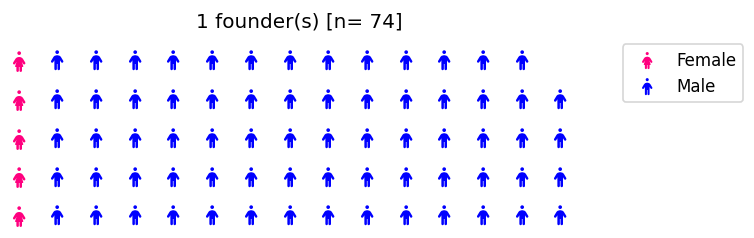

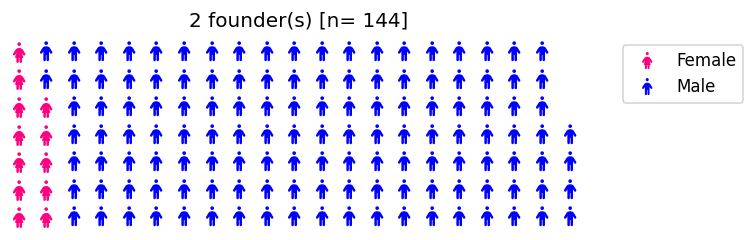

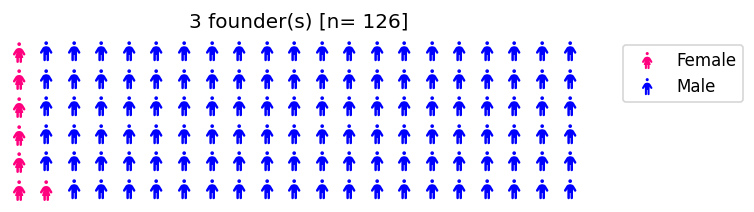

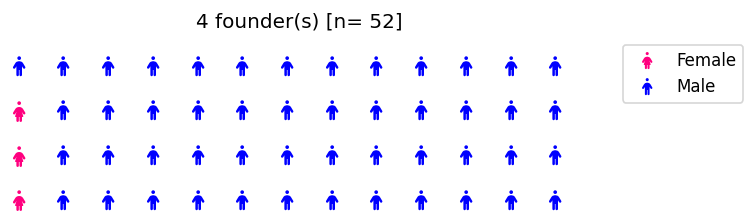

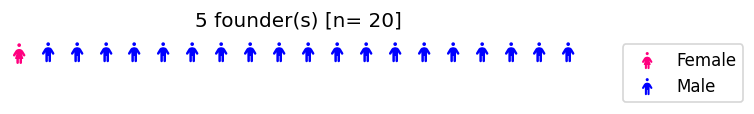

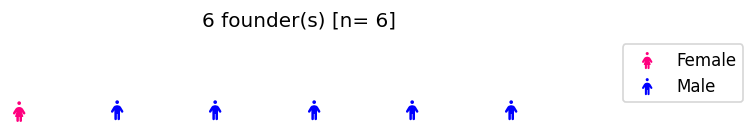

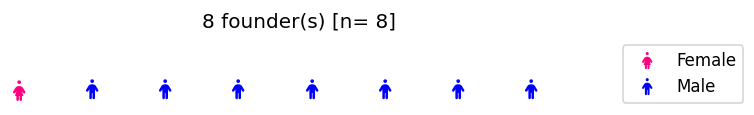

In [203]:
from pywaffle import Waffle
import matplotlib.pyplot as plt
from matplotlib import rcParams

row_length = [5,7,6,4,1,1,1]
for founder_number1, female, male, row in zip(founder_number, total_female_founders, total_male_founders, row_length):


    total_male = male
    total_female = female


    rcParams["figure.dpi"] = 120
    fig = plt.figure(
        FigureClass=Waffle,
        rows= row,                 # try smaller first if still cramped (e.g., 10–15)
        values=[female, male],
        colors=["#ff007f", "#0000FF"],
        icons=["female", "male"],
        font_size=12,             # was 20
        icon_style="solid",
        icon_legend=True,
        legend={
            "labels": ["Female", "Male"],
            "loc": "upper left",
            "bbox_to_anchor": (1.05, 1),   # give legend a bit more breathing room
        },
    )
    plt.title(str(founder_number1) + " founder(s) [n= "+ str(female+male) + "]")
    plt.show()